# Panel Regression: Fixed & Random Effects

## Research Question
**Is biodiversity loss in beef-exporting countries associated with the volume of beef exports to the United Kingdom?**

## Approach
We use the **extended panel (2010-2020)** created in the data-cleaning notebook
(historical BIO 2010-2014 + SSP2 projections 2015-2020, merged with FAOSTAT bilateral trade).

| Model | What it controls for |
|-------|---------------------|
| **Pooled OLS** | Baseline - ignores panel structure |
| **Fixed Effects (FE)** | All *time-invariant* country characteristics |
| **Random Effects (RE)** | Treats country effects as random draws - more efficient if valid |
| **Hausman test** | Decides whether FE or RE is appropriate |

### Model Specification
$$\text{log\_uk\_import\_qty\_t}_{it} = \alpha_i + \beta \cdot \text{bii\_loss}_{it} + \varepsilon_{it}$$

- $i$ = country, $t$ = year
- $\alpha_i$ = country-specific intercept (fixed or random)
- All regressions use **clustered standard errors** at the country level


---
## 0 - Setup


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')

# Paths (notebook lives in data/)
DATA  = os.path.dirname(os.path.abspath('__file__'))
CLEAN = os.path.join(DATA, 'clean')

print('Ready.')


Ready.


---
## 1 - Load Extended Panel


In [2]:
panel = pd.read_csv(os.path.join(CLEAN, 'panel_extended_2010_2020.csv'))

print(f'Shape: {panel.shape}')
print(f'Countries: {panel["iso3"].nunique()}')
print(f'Years: {sorted(panel["year"].unique())}')
print(f'Bio source breakdown:')
print(panel['bio_source'].value_counts())
panel.head()


Shape: (292, 8)
Countries: 32
Years: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
Bio source breakdown:
bio_source
ssp2_projected    158
historical        134
Name: count, dtype: int64


,iso3,country,year,uk_import_qty_t,log_uk_import_qty_t,bii,bii_loss,bio_source
0,ARG,Argentina,2010,1959.0,7.580700,0.725217,0.274783,historical
1,ARG,Argentina,2011,1322.0,7.187657,0.723646,0.276354,historical
2,ARG,Argentina,2012,1182.0,7.075809,0.721324,0.278676,historical
3,ARG,Argentina,2013,314.0,5.752573,0.715945,0.284055,historical
4,ARG,Argentina,2014,58.4,4.084294,0.711267,0.288733,historical


### 1.1 - Panel Balance Check
The panel is **unbalanced** - not every country is observed in every year.
Both `PanelOLS` (FE) and `RandomEffects` (RE) handle unbalanced panels correctly.


In [3]:
balance = panel.groupby('iso3')['year'].count().describe()
print('Observations per country (summary):')
print(balance.round(1))

presence = panel.pivot_table(index='iso3', columns='year',
                             values='bii_loss', aggfunc='count')
print(f'\nCountries with all 11 years: {(presence.sum(axis=1) == 11).sum()}')
print(f'Countries with < 5 years:    {(presence.sum(axis=1) < 5).sum()}')


Observations per country (summary):
count    32.0
mean      9.1
std       2.8
min       1.0
25%       7.8
50%      11.0
75%      11.0
max      11.0
Name: year, dtype: float64

Countries with all 11 years: 17
Countries with < 5 years:    3


### 1.2 - Descriptive Statistics


In [4]:
desc_cols = ['bii', 'bii_loss', 'uk_import_qty_t', 'log_uk_import_qty_t']
print('Overall summary statistics:')
panel[desc_cols].describe().round(4)


Overall summary statistics:


,bii,bii_loss,uk_import_qty_t,log_uk_import_qty_t
count,292.0000,292.0000,292.0000,292.0000
mean,0.6772,0.3228,2896.5603,4.2896
std,0.1296,0.1296,8793.0253,3.0161
min,0.3307,0.0471,0.0200,0.0198
25%,0.6110,0.2706,3.4975,1.5035
50%,0.6799,0.3201,41.0700,3.7391
75%,0.7294,0.3890,876.7500,6.7773
max,0.9529,0.6693,46492.0000,10.7471


### 1.3 - Within vs. Between Variation
Fixed effects exploit **within-country** variation over time.
If most variation in `bii_loss` is *between* countries, FE will have low power.


In [5]:
for col in ['bii_loss', 'log_uk_import_qty_t']:
    overall_var = panel[col].var()
    between_var = panel.groupby('iso3')[col].mean().var()
    within_var  = panel.groupby('iso3')[col].apply(lambda x: x - x.mean()).var()
    print(f'{col}:')
    print(f'  Overall variance:  {overall_var:.6f}')
    print(f'  Between variance:  {between_var:.6f}  ({between_var/overall_var*100:.1f}%)')
    print(f'  Within variance:   {within_var:.6f}  ({within_var/overall_var*100:.1f}%)')
    print()


bii_loss:
  Overall variance:  0.016806
  Between variance:  0.018561  (110.4%)
  Within variance:   0.000039  (0.2%)

log_uk_import_qty_t:
  Overall variance:  9.097137
  Between variance:  7.524473  (82.7%)
  Within variance:   1.013626  (11.1%)



---
## 2 - Set Multi-Index for Panel Models
`linearmodels` requires a `MultiIndex` of `(entity, time)` - here `(iso3, year)`.


In [6]:
panel = panel.set_index(['iso3', 'year'])
panel.index.names = ['iso3', 'year']
print(f'Index: {panel.index.names}')
panel.head()


Index: ['iso3', 'year']


country  uk_import_qty_t  log_uk_import_qty_t       bii  bii_loss  bio_source
iso3 year                                                                                 
ARG  2010  Argentina           1959.0             7.580700  0.725217  0.274783  historical
     2011  Argentina           1322.0             7.187657  0.723646  0.276354  historical
     2012  Argentina           1182.0             7.075809  0.721324  0.278676  historical
     2013  Argentina            314.0             5.752573  0.715945  0.284055  historical
     2014  Argentina             58.4             4.084294  0.711267  0.288733  historical

---
## 3 - Pooled OLS (Baseline)
Ignores the panel structure - treats all observations as independent.
Standard errors are **clustered at the country level**.


In [7]:
dep_var = panel['log_uk_import_qty_t']
exog    = sm.add_constant(panel[['bii_loss']])

pooled_model = PooledOLS(dep_var, exog)
pooled_res   = pooled_model.fit(cov_type='clustered', cluster_entity=True)

print(pooled_res.summary)


                           PooledOLS Estimation Summary                          
Dep. Variable:     log_uk_import_qty_t   R-squared:                        0.1103
Estimator:                   PooledOLS   R-squared (Between):              0.1268
No. Observations:                  292   R-squared (Within):              -0.0200
Date:                 Thu, Apr 02 2026   R-squared (Overall):              0.1103
Time:                         20:23:45   Log-likelihood                   -719.13
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      35.943
Entities:                           32   P-value                           0.0000
Avg Obs:                        9.1250   Distribution:                   F(1,290)
Min Obs:                        1.0000                                           
Max Obs:                        11.000   F-statistic (robust):             3.9431
                

---
## 4 - Fixed Effects (FE) - Entity Demeaning

Controls for all **time-invariant** country characteristics.
The coefficient on `bii_loss` captures the **within-country** relationship:
*when a country's biodiversity loss increases over time, do its beef exports to the UK change?*


In [14]:
# 4a. Entity FE only
fe_model = PanelOLS(dep_var, panel[['bii_loss']], entity_effects=True)
fe_res   = fe_model.fit(cov_type='clustered', cluster_entity=True)

print('=' * 70)
print('FIXED EFFECTS - Entity only')
print('=' * 70)
print(fe_res.summary)


FIXED EFFECTS - Entity only
                           PanelOLS Estimation Summary                           
Dep. Variable:     log_uk_import_qty_t   R-squared:                        0.0341
Estimator:                    PanelOLS   R-squared (Between):             -7.9116
No. Observations:                  292   R-squared (Within):               0.0341
Date:                 Thu, Apr 02 2026   R-squared (Overall):             -7.1954
Time:                         20:24:48   Log-likelihood                   -410.74
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      9.1451
Entities:                           32   P-value                           0.0027
Avg Obs:                        9.1250   Distribution:                   F(1,259)
Min Obs:                        1.0000                                           
Max Obs:                        11.000   F-statistic (robust):        

In [15]:
# 4b. Entity + Time FE (two-way)
fe2_model = PanelOLS(dep_var, panel[['bii_loss']],
                     entity_effects=True, time_effects=True)
fe2_res   = fe2_model.fit(cov_type='clustered', cluster_entity=True)

print('=' * 70)
print('FIXED EFFECTS - Entity + Time (two-way)')
print('=' * 70)
print(fe2_res.summary)


FIXED EFFECTS - Entity + Time (two-way)
                           PanelOLS Estimation Summary                           
Dep. Variable:     log_uk_import_qty_t   R-squared:                        0.0389
Estimator:                    PanelOLS   R-squared (Between):             -8.6083
No. Observations:                  292   R-squared (Within):               0.0340
Date:                 Thu, Apr 02 2026   R-squared (Overall):             -7.8248
Time:                         20:25:02   Log-likelihood                   -404.90
Cov. Estimator:              Clustered                                           
                                         F-statistic:                      10.084
Entities:                           32   P-value                           0.0017
Avg Obs:                        9.1250   Distribution:                   F(1,249)
Min Obs:                        1.0000                                           
Max Obs:                        11.000   F-statistic (robu

### 4.1 - F-test for Joint Significance of Entity Effects
Tests whether the country fixed effects are *jointly significant*.


In [16]:
print('F-test for poolability (entity effects = 0):')
print(f'  F-statistic: {fe_res.f_poolable.stat:.4f}')
print(f'  p-value:     {fe_res.f_poolable.pval:.6f}')
if fe_res.f_poolable.pval < 0.05:
    print('  => Reject H0: entity effects ARE significant - pooled OLS is inappropriate.')
else:
    print('  => Cannot reject H0: entity effects not significant - pooled OLS may suffice.')


F-test for poolability (entity effects = 0):


AttributeError: 'PanelEffectsResults' object has no attribute 'f_poolable'

---
## 5 - Random Effects (RE)

RE is more **efficient** than FE (uses both within *and* between variation)
but requires that country effects are uncorrelated with the regressors.
The Hausman test (next section) evaluates this assumption.


In [17]:
re_model = RandomEffects(dep_var, exog)
re_res   = re_model.fit(cov_type='clustered', cluster_entity=True)

print('=' * 70)
print('RANDOM EFFECTS')
print('=' * 70)
print(re_res.summary)


RANDOM EFFECTS
                         RandomEffects Estimation Summary                        
Dep. Variable:     log_uk_import_qty_t   R-squared:                       -0.0042
Estimator:               RandomEffects   R-squared (Between):              0.0925
No. Observations:                  292   R-squared (Within):              -0.0080
Date:                 Thu, Apr 02 2026   R-squared (Overall):              0.0698
Time:                         20:25:21   Log-likelihood                   -433.10
Cov. Estimator:              Clustered                                           
                                         F-statistic:                     -1.2250
Entities:                           32   P-value                           1.0000
Avg Obs:                        9.1250   Distribution:                   F(1,290)
Min Obs:                        1.0000                                           
Max Obs:                        11.000   F-statistic (robust):             0.6932
 

---
## 6 - Hausman Test: FE vs RE

- **H0**: RE is consistent and efficient (country effects uncorrelated with regressors).
- **H1**: RE is inconsistent - use FE.

We compare the `bii_loss` coefficient from both models.


In [18]:
# Manual Hausman test
b_fe = fe_res.params['bii_loss']
b_re = re_res.params['bii_loss']

var_fe = fe_res.std_errors['bii_loss'] ** 2
var_re = re_res.std_errors['bii_loss'] ** 2

var_diff = var_fe - var_re

if var_diff > 0:
    hausman_stat = (b_fe - b_re) ** 2 / var_diff
    hausman_pval = 1 - stats.chi2.cdf(hausman_stat, df=1)

    print('Hausman Test  (FE vs RE)')
    print('=' * 50)
    print(f'  FE coeff (bii_loss):  {b_fe:>10.4f}')
    print(f'  RE coeff (bii_loss):  {b_re:>10.4f}')
    print(f'  Difference:           {b_fe - b_re:>10.4f}')
    print(f'  Hausman chi2(1):      {hausman_stat:>10.4f}')
    print(f'  p-value:              {hausman_pval:>10.6f}')
    print()
    if hausman_pval < 0.05:
        print('  => Reject H0 at 5%: FE is preferred (RE is inconsistent).')
        preferred = 'FE'
    else:
        print('  => Cannot reject H0: RE is preferred (more efficient & consistent).')
        preferred = 'RE'
else:
    print('  Var(b_FE) < Var(b_RE) -- Hausman statistic is negative.')
    print('  This can happen in finite samples with clustered SEs.')
    print('  Interpreting as: no strong evidence against RE.')
    preferred = 'RE'

print(f'\n  >> Preferred model: {preferred}')


Hausman Test  (FE vs RE)
  FE coeff (bii_loss):    -29.7993
  RE coeff (bii_loss):      3.3276
  Difference:             -33.1269
  Hausman chi2(1):          4.1422
  p-value:                0.041828

  => Reject H0 at 5%: FE is preferred (RE is inconsistent).

  >> Preferred model: FE


---
## 7 - Model Comparison Table


In [19]:
comparison = compare(
    {
        'Pooled OLS':     pooled_res,
        'FE (entity)':    fe_res,
        'FE (two-way)':   fe2_res,
        'Random Effects': re_res,
    },
    stars=True,
)
print(comparison.summary)


                                                    Model Comparison                                                   
                                     Pooled OLS             FE (entity)            FE (two-way)          Random Effects
-----------------------------------------------------------------------------------------------------------------------
Dep. Variable               log_uk_import_qty_t     log_uk_import_qty_t     log_uk_import_qty_t     log_uk_import_qty_t
Estimator                             PooledOLS                PanelOLS                PanelOLS           RandomEffects
No. Observations                            292                     292                     292                     292
Cov. Est.                             Clustered               Clustered               Clustered               Clustered
R-squared                                0.1103                  0.0341                  0.0389                 -0.0042
R-Squared (Within)                      

---
## 8 - Diagnostics


### 8.1 - Residuals from the Preferred Model


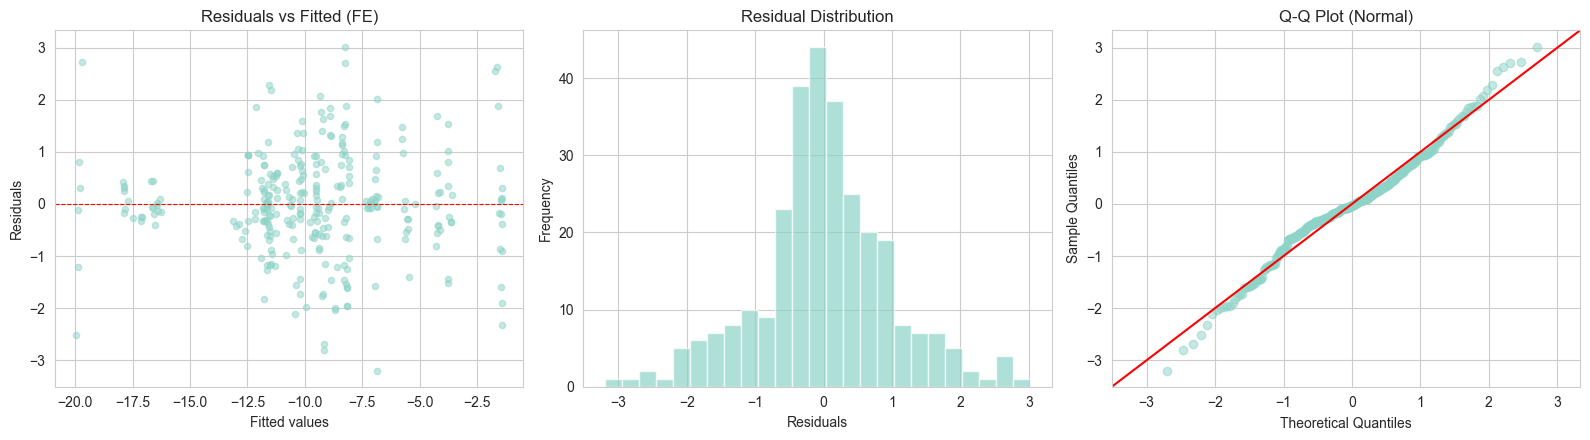

Saved => data/clean/fe_re_diagnostics.png


In [20]:
preferred_res = fe_res if preferred == 'FE' else re_res
resids = preferred_res.resids.copy()
fitted = preferred_res.fitted_values.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Residuals vs Fitted
axes[0].scatter(fitted, resids, alpha=0.5, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title(f'Residuals vs Fitted ({preferred})')

# (b) Histogram of residuals
axes[1].hist(resids, bins=25, edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# (c) Q-Q plot
sm.qqplot(resids.values.flatten(), line='45', ax=axes[2], alpha=0.5)
axes[2].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.savefig(os.path.join(CLEAN, 'fe_re_diagnostics.png'), dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved => data/clean/fe_re_diagnostics.png')


### 8.2 - Country Fixed Effects (Estimated alpha_i)


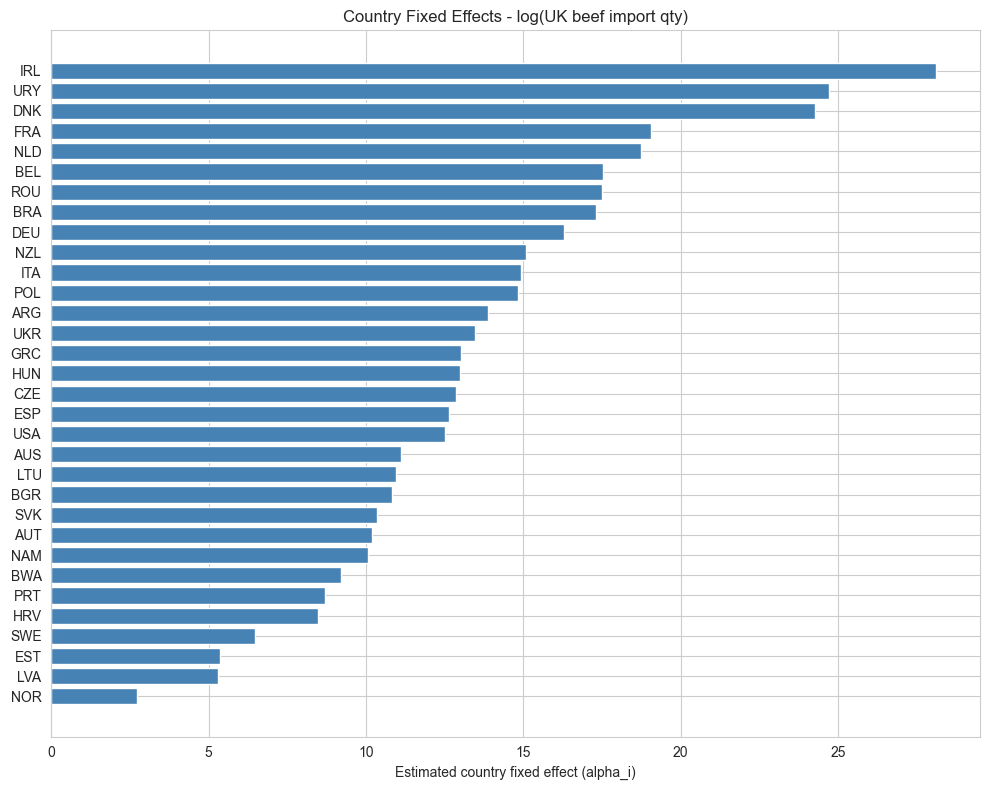

Saved => data/clean/country_fixed_effects.png


In [21]:
if preferred == 'FE':
    effects = fe_res.estimated_effects.copy()
    effects.columns = ['alpha_i']
    effects = (effects.reset_index()
              .drop_duplicates(subset='iso3')
              .set_index('iso3')
              .sort_values('alpha_i', ascending=True))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(effects.index, effects['alpha_i'],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Estimated country fixed effect (alpha_i)')
    ax.set_title('Country Fixed Effects - log(UK beef import qty)')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(CLEAN, 'country_fixed_effects.png'), dpi=150,
                bbox_inches='tight')
    plt.show()
    print('Saved => data/clean/country_fixed_effects.png')
else:
    print('RE preferred - no entity-specific intercepts to plot.')


### 8.3 - Within-Country Time Trends (Spaghetti Plot)


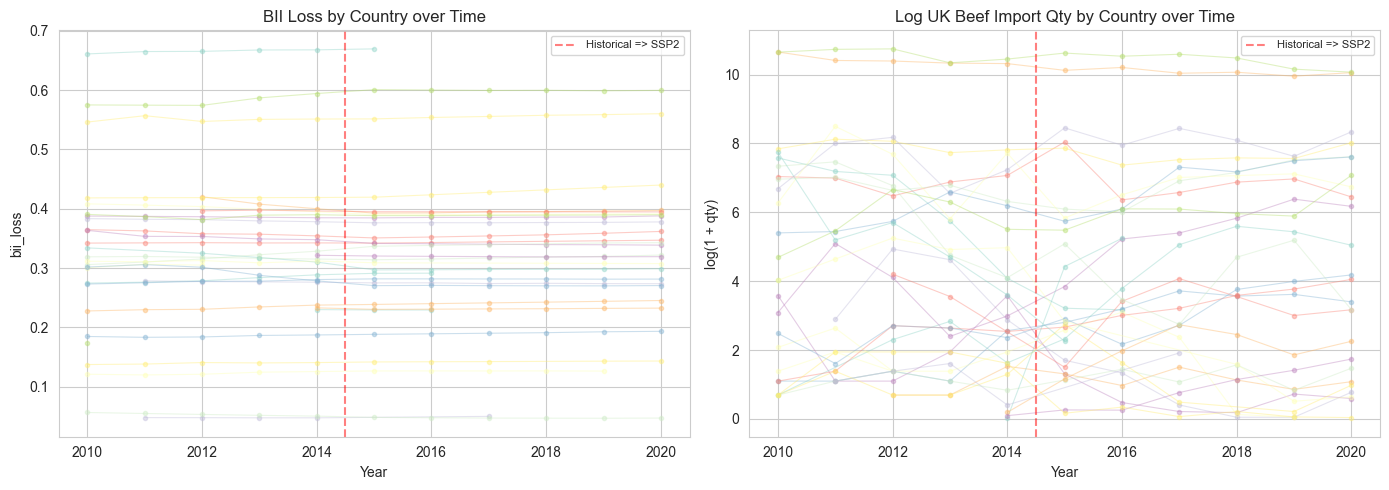

Saved => data/clean/spaghetti_trends.png


In [22]:
plot_df = panel.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for iso3, grp in plot_df.groupby('iso3'):
    axes[0].plot(grp['year'], grp['bii_loss'],
                marker='.', alpha=0.4, linewidth=0.8)
    axes[1].plot(grp['year'], grp['log_uk_import_qty_t'],
                marker='.', alpha=0.4, linewidth=0.8)

axes[0].set_title('BII Loss by Country over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('bii_loss')

axes[1].set_title('Log UK Beef Import Qty by Country over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('log(1 + qty)')

for ax in axes:
    ax.axvline(2014.5, color='red', linestyle='--', alpha=0.5,
              label='Historical => SSP2')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CLEAN, 'spaghetti_trends.png'), dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved => data/clean/spaghetti_trends.png')


---
## 9 - Robustness Checks


### 9.1 - Restrict to Historical Data Only (2010-2014)
Excludes SSP2 projections to verify results hold on observed data alone.


In [23]:
panel_hist = panel[panel['bio_source'] == 'historical'].copy()
print(f'Historical-only panel: {panel_hist.shape[0]} obs, '
      f'{panel_hist.reset_index()["iso3"].nunique()} countries, '
      f'{panel_hist.reset_index()["year"].nunique()} years')

dep_hist = panel_hist['log_uk_import_qty_t']

# FE on historical only
fe_hist = PanelOLS(dep_hist, panel_hist[['bii_loss']], entity_effects=True)
fe_hist_res = fe_hist.fit(cov_type='clustered', cluster_entity=True)

# RE on historical only
exog_hist = sm.add_constant(panel_hist[['bii_loss']])
re_hist = RandomEffects(dep_hist, exog_hist)
re_hist_res = re_hist.fit(cov_type='clustered', cluster_entity=True)

print('\n--- FE (historical only) ---')
print(f'  bii_loss coeff: {fe_hist_res.params["bii_loss"]:.4f}  '
      f'(SE: {fe_hist_res.std_errors["bii_loss"]:.4f}, '
      f'p: {fe_hist_res.pvalues["bii_loss"]:.4f})')

print('\n--- RE (historical only) ---')
print(f'  bii_loss coeff: {re_hist_res.params["bii_loss"]:.4f}  '
      f'(SE: {re_hist_res.std_errors["bii_loss"]:.4f}, '
      f'p: {re_hist_res.pvalues["bii_loss"]:.4f})')


Historical-only panel: 134 obs, 32 countries, 5 years

--- FE (historical only) ---
  bii_loss coeff: -28.7537  (SE: 15.8005, p: 0.0718)

--- RE (historical only) ---
  bii_loss coeff: 6.2393  (SE: 3.5129, p: 0.0780)


### 9.2 - Exclude Dominant Exporters (Ireland & Brazil)
Ireland and Brazil account for the vast majority of UK beef imports.
We check whether results are driven by these two countries.


In [24]:
excl = panel[~panel.reset_index()['iso3'].isin(['IRL', 'BRA']).values].copy()
print(f'Panel excluding IRL & BRA: {excl.shape[0]} obs, '
      f'{excl.reset_index()["iso3"].nunique()} countries')

dep_excl = excl['log_uk_import_qty_t']

fe_excl = PanelOLS(dep_excl, excl[['bii_loss']], entity_effects=True)
fe_excl_res = fe_excl.fit(cov_type='clustered', cluster_entity=True)

print(f'\n  bii_loss coeff: {fe_excl_res.params["bii_loss"]:.4f}  '
      f'(SE: {fe_excl_res.std_errors["bii_loss"]:.4f}, '
      f'p: {fe_excl_res.pvalues["bii_loss"]:.4f})')
print(f'  R-sq (within): {fe_excl_res.rsquared_within:.4f}')


Panel excluding IRL & BRA: 270 obs, 30 countries

  bii_loss coeff: -32.1982  (SE: 19.2766, p: 0.0962)
  R-sq (within): 0.0341


### 9.3 - Balanced Sub-Panel (Countries with >= 8 Years)
Restricts to countries observed in most years to reduce attrition bias.


In [25]:
year_counts = panel.reset_index().groupby('iso3')['year'].count()
keep_iso3 = year_counts[year_counts >= 8].index

balanced = panel[panel.reset_index()['iso3'].isin(keep_iso3).values].copy()
print(f'Near-balanced panel (>=8 years): {balanced.shape[0]} obs, '
      f'{balanced.reset_index()["iso3"].nunique()} countries')

dep_bal = balanced['log_uk_import_qty_t']

fe_bal = PanelOLS(dep_bal, balanced[['bii_loss']], entity_effects=True)
fe_bal_res = fe_bal.fit(cov_type='clustered', cluster_entity=True)

print(f'\n  bii_loss coeff: {fe_bal_res.params["bii_loss"]:.4f}  '
      f'(SE: {fe_bal_res.std_errors["bii_loss"]:.4f}, '
      f'p: {fe_bal_res.pvalues["bii_loss"]:.4f})')
print(f'  R-sq (within): {fe_bal_res.rsquared_within:.4f}')


Near-balanced panel (>=8 years): 253 obs, 24 countries

  bii_loss coeff: -20.5489  (SE: 16.6384, p: 0.2181)
  R-sq (within): 0.0201


---
## 10 - Summary of Results


In [27]:
results = pd.DataFrame({
    'Model': [
        'Pooled OLS',
        'FE (entity)',
        'FE (entity + time)',
        'Random Effects',
        'FE - historical only',
        'FE - excl. IRL & BRA',
        'FE - balanced (>=8 yrs)',
    ],
    'beta_bii_loss': [
        pooled_res.params['bii_loss'],
        fe_res.params['bii_loss'],
        fe2_res.params['bii_loss'],
        re_res.params['bii_loss'],
        fe_hist_res.params['bii_loss'],
        fe_excl_res.params['bii_loss'],
        fe_bal_res.params['bii_loss'],
    ],
    'SE': [
        pooled_res.std_errors['bii_loss'],
        fe_res.std_errors['bii_loss'],
        fe2_res.std_errors['bii_loss'],
        re_res.std_errors['bii_loss'],
        fe_hist_res.std_errors['bii_loss'],
        fe_excl_res.std_errors['bii_loss'],
        fe_bal_res.std_errors['bii_loss'],
    ],
    'p_value': [
        pooled_res.pvalues['bii_loss'],
        fe_res.pvalues['bii_loss'],
        fe2_res.pvalues['bii_loss'],
        re_res.pvalues['bii_loss'],
        fe_hist_res.pvalues['bii_loss'],
        fe_excl_res.pvalues['bii_loss'],
        fe_bal_res.pvalues['bii_loss'],
    ],
    'N': [
        int(pooled_res.nobs),
        int(fe_res.nobs),
        int(fe2_res.nobs),
        int(re_res.nobs),
        int(fe_hist_res.nobs),
        int(fe_excl_res.nobs),
        int(fe_bal_res.nobs),
    ],
})

results['Sig.'] = results['p_value'].apply(
    lambda p: '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
)

print('Summary of all panel regression results')
print('=' * 85)
print(results.to_string(index=False, float_format='{:.4f}'.format))


Summary of all panel regression results
                  Model  beta_bii_loss      SE  p_value   N Sig.
             Pooled OLS         7.7260  3.8908   0.0480 292   **
            FE (entity)       -29.7993 16.7602   0.0766 292    *
     FE (entity + time)       -31.4557 19.3197   0.1048 292     
         Random Effects         3.3276  3.9967   0.4058 292     
   FE - historical only       -28.7537 15.8005   0.0718 134    *
   FE - excl. IRL & BRA       -32.1982 19.2766   0.0962 270    *
FE - balanced (>=8 yrs)       -20.5489 16.6384   0.2181 253     


In [28]:
# Save results table
results.to_csv(os.path.join(CLEAN, 'panel_regression_results.csv'), index=False)
print('Saved => data/clean/panel_regression_results.csv')


Saved => data/clean/panel_regression_results.csv


---
## 11 - Interpretation

### Key Findings

1. **F-test for entity effects** - if significant, pooled OLS is inappropriate and
   we need to account for unobserved country heterogeneity.

2. **Hausman test** - determines whether Fixed Effects or Random Effects is the
   appropriate estimator.

3. **Coefficient on `bii_loss`** - interpretation depends on the preferred model:
   - *FE*: a one-unit increase in biodiversity loss **within a country over time**
     is associated with a beta-unit change in log UK beef import quantity.
   - *RE*: same, but exploits both within- and between-country variation.

4. **Robustness**: restricting to historical data only, excluding dominant
   exporters, and using a near-balanced panel tests whether the main result
   is sensitive to these choices.

### Limitations
- BIO data after 2014 are **SSP2 projections**, not observed values.
- The panel is **unbalanced** (not all countries trade in every year).
- **Omitted variable bias** is possible - FE controls for time-invariant
  confounders but not time-varying ones (e.g., trade policy changes).
- With ~32 countries the cluster count is modest, which may affect
  clustered standard error inference.
